# E9 222 Signal Processing in Practise - Assignment 14
***
*Submitted by: Dwaipayan Haldar*<br>
*S.R. No. : 27128*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Use MPS (Apple Silicon) if available, else CUDA, else CPU
device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


---
## Q1: OFDM Channel Estimation Using LS, MMSE, and DNN

**System**: N=256 subcarriers, CP=16, channel length L=16 (≤ CP to avoid ISI).  
Frame structure: **Pilot Frame** [CP(16) | Pilot(256)] followed by **Data Frame** [CP(16) | Data(256)].  
SNR range: −10 dB to +30 dB in steps of 5 dB (9 points), 5000 samples per SNR.

In [2]:
# ── Q1 System Parameters ─────────────────────────────────────────────────────
N   = 256   # FFT size (number of subcarriers)
CP  = 16    # Cyclic prefix length = N/16
L   = 16    # Multipath channel length (≤ CP ensures no ISI)
N_SAMPLES = 5000                          # samples per SNR point
SNR_DB    = np.arange(-10, 31, 5)        # 9 SNR points: -10,-5,...,+30 dB
print(f"SNR points: {SNR_DB}")

# ── Channel generation (i.i.d. Rayleigh, total power = 1) ───────────────────
def gen_channel(L):
    """Complex Gaussian channel: each tap ~ CN(0, 1/L), total power = 1."""
    return (np.random.randn(L) + 1j * np.random.randn(L)) / np.sqrt(2 * L)

# ── OFDM TX→channel→RX for one frame ────────────────────────────────────────
def ofdm_frame(X_sym, h, N, CP, snr_lin):
    """
    Transmit frequency-domain symbols X_sym through channel h and AWGN.
    SNR convention: SNR_lin = E_s / N_0 per subcarrier (E_s=1 for unit-power pilots/data).
    Noise N_0 = 1/(N*snr_lin) → freq-domain noise variance = N*N_0 = 1/snr_lin.
    Returns: Y (N-point frequency-domain received signal)
    """
    x_time = np.fft.ifft(X_sym)                                 # IFFT (OFDM modulation)
    x_cp   = np.concatenate([x_time[-CP:], x_time])             # prepend cyclic prefix
    y_conv = np.convolve(h, x_cp)[:N + CP]                      # channel convolution
    # Time-domain AWGN: noise_std per real/imag = sqrt(N_0/2) = sqrt(1/(2*N*snr_lin))
    noise_std = np.sqrt(1.0 / (2.0 * N * snr_lin))
    noise = noise_std * (np.random.randn(N + CP) + 1j * np.random.randn(N + CP))
    Y = np.fft.fft((y_conv + noise)[CP:])                       # remove CP, FFT
    return Y

# ── Precompute channel frequency-domain covariance R_HH ─────────────────────
def compute_R_HH(N, L):
    """
    R_HH[k,m] = E[H[k]*H[m]*] = (1/L) * sum_{l=0}^{L-1} exp(-j2π*l*(k-m)/N)
    Assumes i.i.d. taps each ~ CN(0, 1/L).
    """
    k_idx = np.arange(N)
    R = np.zeros((N, N), dtype=complex)
    for l in range(L):
        v = np.exp(-1j * 2 * np.pi * l * k_idx / N)   # steering vector for tap l
        R += np.outer(v, v.conj()) / L
    return R

R_HH = compute_R_HH(N, L)
print(f"R_HH computed: {R_HH.shape}")

SNR points: [-10  -5   0   5  10  15  20  25  30]
R_HH computed: (256, 256)


In [3]:
# ── Q1 Data Generation ────────────────────────────────────────────────────────
# For each sample: pilot frame + data frame through the same channel.
# Pilot: X_pilot = ones(N)  → all-ones BPSK pilots (known at receiver)
# Data:  4-QAM symbols with unit power: {±1/√2 ± j/√2}

def generate_q1_dataset(snr_db, n_samples, N, CP, L):
    """
    Returns arrays needed for Q1:
      Y_pilot : (n_samples, N) complex  – received pilot frame (freq domain)
      Y_data  : (n_samples, N) complex  – received data frame  (freq domain)
      H_true  : (n_samples, N) complex  – true channel freq response
      X_data  : (n_samples, N) complex  – transmitted 4-QAM symbols
      bits_I  : (n_samples, N) int      – I-branch bits
      bits_Q  : (n_samples, N) int      – Q-branch bits
    """
    snr_lin  = 10 ** (snr_db / 10)
    X_pilot  = np.ones(N, dtype=complex)        # all-ones pilot (unit power, known)

    Y_pilot = np.zeros((n_samples, N), dtype=complex)
    Y_data  = np.zeros((n_samples, N), dtype=complex)
    H_true  = np.zeros((n_samples, N), dtype=complex)
    X_data  = np.zeros((n_samples, N), dtype=complex)
    bits_I  = np.zeros((n_samples, N), dtype=int)
    bits_Q  = np.zeros((n_samples, N), dtype=int)

    for i in range(n_samples):
        h = gen_channel(L)
        H_true[i] = np.fft.fft(h, N)            # true channel freq response

        # Pilot frame
        Y_pilot[i] = ofdm_frame(X_pilot, h, N, CP, snr_lin)

        # Data frame: 4-QAM, unit power per subcarrier
        bI = np.random.randint(0, 2, N)
        bQ = np.random.randint(0, 2, N)
        Xd = (2 * bI - 1) / np.sqrt(2) + 1j * (2 * bQ - 1) / np.sqrt(2)
        Y_data[i]  = ofdm_frame(Xd, h, N, CP, snr_lin)
        X_data[i]  = Xd
        bits_I[i]  = bI
        bits_Q[i]  = bQ

    return Y_pilot, Y_data, H_true, X_data, bits_I, bits_Q


# ── LS and MMSE estimators ────────────────────────────────────────────────────
def ls_estimate(Y_pilot, X_pilot):
    """LS: H_LS = Y_pilot / X_pilot (element-wise)."""
    return Y_pilot / X_pilot                         # (n_samples, N)

def mmse_estimate_batch(H_LS, R_HH, snr_lin, N):
    """
    MMSE: H_MMSE = W * H_LS,  W = R_HH * (R_HH + sigma_f^2 * I)^{-1}
    where sigma_f^2 = 1/snr_lin is the freq-domain noise variance per subcarrier.
    W is (N,N); applied per sample.
    """
    sigma_f2 = 1.0 / snr_lin
    W = R_HH @ np.linalg.inv(R_HH + sigma_f2 * np.eye(N))   # (N,N) MMSE filter
    return (W @ H_LS.T).T                                      # (n_samples, N)

def nmse(H_true, H_hat):
    """NMSE = E[||H - H_hat||^2 / ||H||^2]."""
    err   = np.sum(np.abs(H_true - H_hat) ** 2, axis=1)
    power = np.sum(np.abs(H_true) ** 2, axis=1)
    return np.mean(err / power)

print("Q1 data-generation and estimation helpers defined.")

Q1 data-generation and estimation helpers defined.


### Q1.1 — NMSE vs SNR (LS, MMSE, DNN)
DNN: Input=512, Output=512, $N_h=3$ hidden layers.  
Local search finds optimal neurons per hidden layer from candidates [64, 128, 256, 512].  
The DNN is retrained independently at each SNR point (3500 train / 750 val / 750 test split).

In [4]:
# ── DNN for channel estimation (Q1.1) ─────────────────────────────────────────
# Input : real+imag parts of Y_pilot → 512-dim vector
# Output: real+imag parts of H_true  → 512-dim vector
# Architecture: FC(512) → [ReLU-FC(nh)]×3 → FC(512)

class ChannelEstDNN(nn.Module):
    def __init__(self, nh):
        super().__init__()
        layers = [nn.Linear(512, nh), nn.ReLU()]
        for _ in range(2):                          # 3 hidden layers total
            layers += [nn.Linear(nh, nh), nn.ReLU()]
        layers.append(nn.Linear(nh, 512))           # output layer
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def to_real_vec(z):
    """Stack real and imaginary parts: (n, N) complex → (n, 2N) float."""
    return np.concatenate([z.real, z.imag], axis=1).astype(np.float32)

def make_loader(X_np, Y_np, batch_size=256, shuffle=True):
    ds = TensorDataset(torch.from_numpy(X_np), torch.from_numpy(Y_np))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def train_dnn(model, tr_loader, va_loader, n_epochs=80, lr=1e-3):
    """Train with MSE loss; return best (val-NMSE) model weights."""
    opt  = optim.Adam(model.parameters(), lr=lr)
    sch  = optim.lr_scheduler.StepLR(opt, step_size=30, gamma=0.5)
    crit = nn.MSELoss()
    best_val, best_w = 1e9, None
    for _ in range(n_epochs):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
        sch.step()
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in va_loader:
                val_loss += crit(model(xb.to(device)), yb.to(device)).item()
        if val_loss < best_val:
            best_val = val_loss
            best_w   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    model.load_state_dict({k: v.to(device) for k, v in best_w.items()})
    return model


def eval_nmse_dnn(model, X_te, H_te_real, H_te_complex):
    """Predict H on test set; compute NMSE against complex H_true."""
    model.eval()
    with torch.no_grad():
        H_pred = model(torch.from_numpy(X_te).to(device)).cpu().numpy()
    # Reconstruct complex from real+imag halves
    H_pred_c = H_pred[:, :256] + 1j * H_pred[:, 256:]
    return nmse(H_te_complex, H_pred_c)


# ── Local search for optimal hidden-layer size (Q1.1) ─────────────────────────
# Use SNR = 10 dB (middle of range) for the local search
CANDIDATES = [64, 128, 256, 512]      # neuron count candidates
print("Running local search for Q1.1 DNN hidden-layer size at SNR=10 dB …")
np.random.seed(0)
Yp_s, _, Ht_s, _, _, _ = generate_q1_dataset(10, 1000, N, CP, L)
Xin_s = to_real_vec(Yp_s)             # input: re+im of received pilot
Yout_s = to_real_vec(Ht_s)            # label: re+im of true channel

# 70/15/15 split on the 1000 search samples
idx = np.random.permutation(1000)
n_tr, n_va = 700, 150
Xtr, Ytr = Xin_s[idx[:n_tr]], Yout_s[idx[:n_tr]]
Xva, Yva = Xin_s[idx[n_tr:n_tr+n_va]], Yout_s[idx[n_tr:n_tr+n_va]]

tr_ld = make_loader(Xtr, Ytr)
va_ld = make_loader(Xva, Yva, shuffle=False)

best_nh_nmse, best_val_nmse = 128, 1e9
for nh in CANDIDATES:
    m = ChannelEstDNN(nh).to(device)
    train_dnn(m, tr_ld, va_ld, n_epochs=40)
    m.eval()
    val_loss = sum(nn.MSELoss()(m(xb.to(device)), yb.to(device)).item()
                   for xb, yb in va_ld)
    print(f"  nh={nh:>4d}  val_MSE={val_loss:.4f}")
    if val_loss < best_val_nmse:
        best_val_nmse, best_nh_nmse = val_loss, nh

print(f"\n→ Optimal hidden neurons for Q1.1: nh = {best_nh_nmse}")

Running local search for Q1.1 DNN hidden-layer size at SNR=10 dB …
  nh=  64  val_MSE=0.1916
  nh= 128  val_MSE=0.0541
  nh= 256  val_MSE=0.0202
  nh= 512  val_MSE=0.0136

→ Optimal hidden neurons for Q1.1: nh = 512


In [5]:
# ── Per-SNR training and NMSE evaluation (Q1.1) ───────────────────────────────
# At each SNR: generate 5000 samples, shuffle, split 70/15/15 (3500/750/750),
# train DNN, and evaluate NMSE for LS, MMSE, and DNN.

X_pilot_vec = np.ones(N, dtype=complex)   # known pilot symbols at receiver

nmse_ls   = np.zeros(len(SNR_DB))
nmse_mmse = np.zeros(len(SNR_DB))
nmse_dnn  = np.zeros(len(SNR_DB))

for si, snr_db in enumerate(tqdm(SNR_DB, desc="Q1.1 NMSE per SNR")):
    snr_lin = 10 ** (snr_db / 10)
    np.random.seed(si)

    # Generate dataset
    Yp, Yd, Ht, Xd, bI, bQ = generate_q1_dataset(snr_db, N_SAMPLES, N, CP, L)

    # LS and MMSE estimates
    H_ls   = ls_estimate(Yp, X_pilot_vec)
    H_mmse = mmse_estimate_batch(H_ls, R_HH, snr_lin, N)

    nmse_ls[si]   = nmse(Ht, H_ls)
    nmse_mmse[si] = nmse(Ht, H_mmse)

    # DNN inputs and labels
    Xin  = to_real_vec(Yp)    # (5000, 512)  – re+im of received pilot
    Yout = to_real_vec(Ht)    # (5000, 512)  – re+im of true channel

    # 70/15/15 shuffle split
    idx  = np.random.permutation(N_SAMPLES)
    ntr, nva = int(0.70 * N_SAMPLES), int(0.15 * N_SAMPLES)
    Xtr, Ytr = Xin[idx[:ntr]],          Yout[idx[:ntr]]
    Xva, Yva = Xin[idx[ntr:ntr+nva]],   Yout[idx[ntr:ntr+nva]]
    Xte, Yte = Xin[idx[ntr+nva:]],      Yout[idx[ntr+nva:]]
    Hte_c    = Ht[idx[ntr+nva:]]        # complex H for NMSE

    # Train DNN
    torch.manual_seed(42)
    model = ChannelEstDNN(best_nh_nmse).to(device)
    tr_ld = make_loader(Xtr, Ytr)
    va_ld = make_loader(Xva, Yva, shuffle=False)
    train_dnn(model, tr_ld, va_ld, n_epochs=80)

    nmse_dnn[si] = eval_nmse_dnn(model, Xte, Yte, Hte_c)
    print(f"  SNR={snr_db:+4.0f} dB | LS={nmse_ls[si]:.4f} | MMSE={nmse_mmse[si]:.4f} | DNN={nmse_dnn[si]:.4f}")

print("\nQ1.1 NMSE evaluation complete.")

Q1.1 NMSE per SNR:   0%|          | 0/9 [00:00<?, ?it/s]

  SNR= -10 dB | LS=10.7183 | MMSE=0.4037 | DNN=0.5220
  SNR=  -5 dB | LS=3.3546 | MMSE=0.1745 | DNN=0.2466
  SNR=  +0 dB | LS=1.0618 | MMSE=0.0621 | DNN=0.1012
  SNR=  +5 dB | LS=0.3373 | MMSE=0.0207 | DNN=0.0390
  SNR= +10 dB | LS=0.1064 | MMSE=0.0066 | DNN=0.0155
  SNR= +15 dB | LS=0.0337 | MMSE=0.0021 | DNN=0.0073
  SNR= +20 dB | LS=0.0107 | MMSE=0.0007 | DNN=0.0047
  SNR= +25 dB | LS=0.0034 | MMSE=0.0002 | DNN=0.0038
  SNR= +30 dB | LS=0.0011 | MMSE=0.0001 | DNN=0.0035

Q1.1 NMSE evaluation complete.


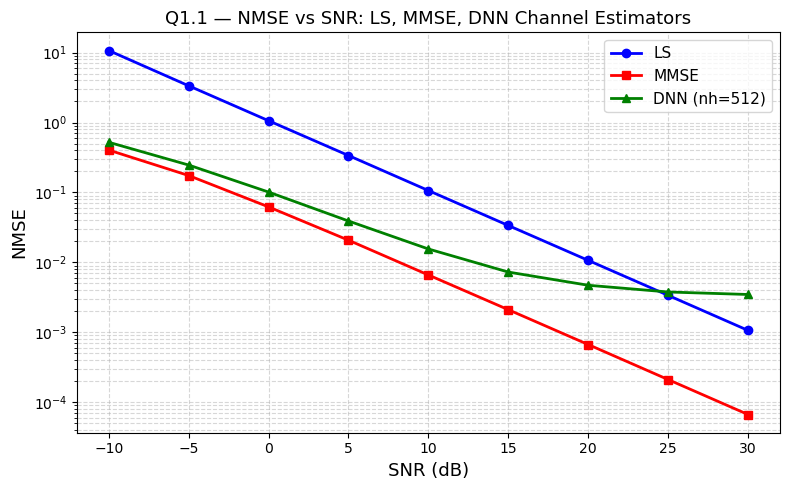

Plot saved: q1_nmse_vs_snr.png


In [6]:
# ── Plot Q1.1: NMSE vs SNR ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(SNR_DB, nmse_ls,   'b-o',  label='LS',   linewidth=2, markersize=6)
ax.semilogy(SNR_DB, nmse_mmse, 'r-s',  label='MMSE', linewidth=2, markersize=6)
ax.semilogy(SNR_DB, nmse_dnn,  'g-^',  label=f'DNN (nh={best_nh_nmse})', linewidth=2, markersize=6)
ax.set_xlabel('SNR (dB)', fontsize=13)
ax.set_ylabel('NMSE', fontsize=13)
ax.set_title('Q1.1 — NMSE vs SNR: LS, MMSE, DNN Channel Estimators', fontsize=13)
ax.legend(fontsize=11); ax.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.savefig('q1_nmse_vs_snr.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: q1_nmse_vs_snr.png")

### Q1.2 — SER vs SNR (LS, MMSE, DNN with 4-QAM)
DNN: Input=1024 (received pilot + data concatenated), Output=512, $N_h=4$ hidden layers.  
ZF equalization is applied after channel estimation for LS and MMSE.  
The DNN directly estimates transmitted symbols from the combined pilot+data input.

In [7]:
# ── DNN for end-to-end equalization (Q1.2) ────────────────────────────────────
# Input : re+im of [Y_pilot | Y_data] → 1024-dim
# Output: re+im of X_data            → 512-dim (estimated transmitted symbols)
# Architecture: FC(1024)→[ReLU-FC(nh)]×4→FC(512)

class EqualizerDNN(nn.Module):
    def __init__(self, nh):
        super().__init__()
        layers = [nn.Linear(1024, nh), nn.ReLU()]
        for _ in range(3):                   # 4 hidden layers total
            layers += [nn.Linear(nh, nh), nn.ReLU()]
        layers.append(nn.Linear(nh, 512))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def detect_4qam(X_hat):
    """Hard-decision 4-QAM detection; returns symbol error mask (n_samples, N)."""
    bI_hat = (X_hat.real > 0).astype(int)
    bQ_hat = (X_hat.imag > 0).astype(int)
    return bI_hat, bQ_hat                    # detected bit streams

def ser_from_bits(bI_hat, bQ_hat, bI_true, bQ_true):
    """SER = fraction of subcarriers with at least one bit error."""
    err = (bI_hat != bI_true) | (bQ_hat != bQ_true)
    return np.mean(err)


# ── Local search for Q1.2 hidden size ────────────────────────────────────────
print("Running local search for Q1.2 DNN hidden-layer size at SNR=10 dB …")
np.random.seed(10)
Yp_s, Yd_s, _, Xd_s, _, _ = generate_q1_dataset(10, 1000, N, CP, L)
Xin_s  = np.concatenate([to_real_vec(Yp_s), to_real_vec(Yd_s)], axis=1)  # (1000,1024)
Yout_s = to_real_vec(Xd_s)                                                # (1000, 512)

idx = np.random.permutation(1000)
Xtr, Ytr = Xin_s[idx[:700]],  Yout_s[idx[:700]]
Xva, Yva = Xin_s[idx[700:850]], Yout_s[idx[700:850]]

tr_ld = make_loader(Xtr, Ytr)
va_ld = make_loader(Xva, Yva, shuffle=False)

best_nh_ser, best_val_ser = 128, 1e9
for nh in CANDIDATES:
    m = EqualizerDNN(nh).to(device)
    train_dnn(m, tr_ld, va_ld, n_epochs=40)
    m.eval()
    vl = sum(nn.MSELoss()(m(xb.to(device)), yb.to(device)).item() for xb, yb in va_ld)
    print(f"  nh={nh:>4d}  val_MSE={vl:.4f}")
    if vl < best_val_ser:
        best_val_ser, best_nh_ser = vl, nh

print(f"\n→ Optimal hidden neurons for Q1.2: nh = {best_nh_ser}")

Running local search for Q1.2 DNN hidden-layer size at SNR=10 dB …
  nh=  64  val_MSE=0.5013
  nh= 128  val_MSE=0.5009
  nh= 256  val_MSE=0.5006
  nh= 512  val_MSE=0.5004

→ Optimal hidden neurons for Q1.2: nh = 512


In [8]:
# ── Per-SNR SER evaluation (Q1.2) ────────────────────────────────────────────
ser_ls   = np.zeros(len(SNR_DB))
ser_mmse = np.zeros(len(SNR_DB))
ser_dnn  = np.zeros(len(SNR_DB))

for si, snr_db in enumerate(tqdm(SNR_DB, desc="Q1.2 SER per SNR")):
    snr_lin = 10 ** (snr_db / 10)
    np.random.seed(si + 100)

    Yp, Yd, Ht, Xd, bI, bQ = generate_q1_dataset(snr_db, N_SAMPLES, N, CP, L)

    # ── LS-ZF SER ─────────────────────────────────────────────────────────────
    H_ls   = ls_estimate(Yp, X_pilot_vec)
    Xhat_ls = Yd / H_ls                              # ZF equalization
    bI_ls, bQ_ls = detect_4qam(Xhat_ls * np.sqrt(2))  # scale back before detection
    ser_ls[si] = ser_from_bits(bI_ls, bQ_ls, bI, bQ)

    # ── MMSE-ZF SER ───────────────────────────────────────────────────────────
    H_mmse  = mmse_estimate_batch(H_ls, R_HH, snr_lin, N)
    Xhat_mm = Yd / H_mmse
    bI_mm, bQ_mm = detect_4qam(Xhat_mm * np.sqrt(2))
    ser_mmse[si] = ser_from_bits(bI_mm, bQ_mm, bI, bQ)

    # ── DNN end-to-end SER ─────────────────────────────────────────────────────
    Xin  = np.concatenate([to_real_vec(Yp), to_real_vec(Yd)], axis=1)  # (5000,1024)
    Yout = to_real_vec(Xd)                                              # (5000, 512)

    idx  = np.random.permutation(N_SAMPLES)
    ntr, nva = int(0.70 * N_SAMPLES), int(0.15 * N_SAMPLES)
    Xtr, Ytr  = Xin[idx[:ntr]],            Yout[idx[:ntr]]
    Xva, Yva  = Xin[idx[ntr:ntr+nva]],     Yout[idx[ntr:ntr+nva]]
    Xte        = Xin[idx[ntr+nva:]]
    bI_te, bQ_te = bI[idx[ntr+nva:]], bQ[idx[ntr+nva:]]

    torch.manual_seed(42)
    model_eq = EqualizerDNN(best_nh_ser).to(device)
    train_dnn(model_eq, make_loader(Xtr, Ytr), make_loader(Xva, Yva, shuffle=False), n_epochs=80)

    model_eq.eval()
    with torch.no_grad():
        Xpred = model_eq(torch.from_numpy(Xte).to(device)).cpu().numpy()
    # Reconstruct complex estimated symbols from re+im halves
    Xpred_c = Xpred[:, :256] + 1j * Xpred[:, 256:]
    bI_dnn, bQ_dnn = detect_4qam(Xpred_c * np.sqrt(2))
    ser_dnn[si] = ser_from_bits(bI_dnn, bQ_dnn, bI_te, bQ_te)

    print(f"  SNR={snr_db:+4.0f} dB | LS={ser_ls[si]:.4f} | MMSE={ser_mmse[si]:.4f} | DNN={ser_dnn[si]:.4f}")

print("\nQ1.2 SER evaluation complete.")

Q1.2 SER per SNR:   0%|          | 0/9 [00:00<?, ?it/s]

  SNR= -10 dB | LS=0.7168 | MMSE=0.6554 | DNN=0.7509
  SNR=  -5 dB | LS=0.6544 | MMSE=0.5485 | DNN=0.7511
  SNR=  +0 dB | LS=0.5174 | MMSE=0.3821 | DNN=0.7493
  SNR=  +5 dB | LS=0.3154 | MMSE=0.2031 | DNN=0.7486
  SNR= +10 dB | LS=0.1436 | MMSE=0.0829 | DNN=0.7507
  SNR= +15 dB | LS=0.0530 | MMSE=0.0289 | DNN=0.7491
  SNR= +20 dB | LS=0.0177 | MMSE=0.0096 | DNN=0.7505
  SNR= +25 dB | LS=0.0058 | MMSE=0.0030 | DNN=0.7486
  SNR= +30 dB | LS=0.0018 | MMSE=0.0009 | DNN=0.7487

Q1.2 SER evaluation complete.


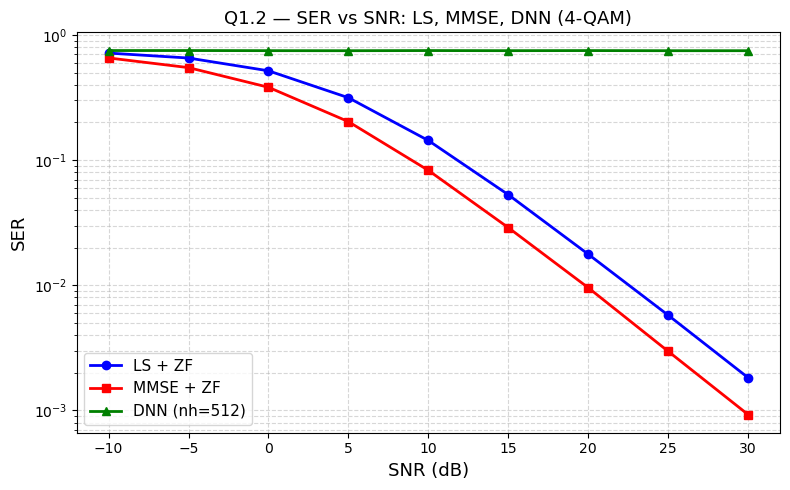

Plot saved: q1_ser_vs_snr.png


In [9]:
# ── Plot Q1.2: SER vs SNR ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(SNR_DB, ser_ls,   'b-o',  label='LS + ZF',   linewidth=2, markersize=6)
ax.semilogy(SNR_DB, ser_mmse, 'r-s',  label='MMSE + ZF', linewidth=2, markersize=6)
ax.semilogy(SNR_DB, ser_dnn,  'g-^',  label=f'DNN (nh={best_nh_ser})', linewidth=2, markersize=6)
ax.set_xlabel('SNR (dB)', fontsize=13)
ax.set_ylabel('SER', fontsize=13)
ax.set_title('Q1.2 — SER vs SNR: LS, MMSE, DNN (4-QAM)', fontsize=13)
ax.legend(fontsize=11); ax.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.savefig('q1_ser_vs_snr.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: q1_ser_vs_snr.png")

---
## Q2: Modulation Classification Using DNN

**System**: N=128 subcarriers, CP=8 (=N/16), channel length L≤8.  
**Classes**: BPSK (class-0), 16-QAM (class-1), 8-PSK (class-2).  
**Dataset**: 128 subcarriers per frame — 43 BPSK + 43 16-QAM + 42 8-PSK, randomly positioned.  
**DNN**: Input=256, Output=128, $N_h=5$ hidden layers. Retrained independently at every SNR point.

In [10]:
# ── Q2 System Parameters ─────────────────────────────────────────────────────
N2  = 128   # FFT size for Q2
CP2 = 8     # Cyclic prefix = N/16 (also ≥ L-1 where L=8)
L2  = 8     # Channel length (≤ CP2 to avoid ISI)

# Class composition: 43 BPSK (0), 43 16-QAM (1), 42 8-PSK (2)
CLASS_COUNTS = [43, 43, 42]   # counts per class, sum = 128

# ── Modulation symbol generators ─────────────────────────────────────────────
def bpsk_symbols(n):
    """n BPSK symbols from {+1, -1}, unit power."""
    return (2 * np.random.randint(0, 2, n) - 1).astype(complex)

def qam16_symbols(n):
    """n 16-QAM symbols from {±1,±3} × {±1,±3}, normalized to unit power."""
    alphabet = np.array([-3, -1, 1, 3], dtype=float)
    re = np.random.choice(alphabet, n)
    im = np.random.choice(alphabet, n)
    s  = (re + 1j * im) / np.sqrt(10)     # normalize: E[|s|^2]=1
    return s

def psk8_symbols(n):
    """n 8-PSK symbols on unit circle, equally spaced."""
    k = np.random.randint(0, 8, n)
    return np.exp(1j * 2 * np.pi * k / 8)  # unit power

# ── Q2 Data Generation ────────────────────────────────────────────────────────
def generate_q2_sample(snr_db, N2, CP2, L2):
    """
    Generate one mixed-modulation OFDM frame (Q2).
    Returns:
      Y_rx     : (N2,) complex  – received frequency-domain signal
      class_idx: (N2,) int      – true class per subcarrier (0,1,2)
    """
    snr_lin = 10 ** (snr_db / 10)

    # Build class-index vector: randomly permute [0]*43 + [1]*43 + [2]*42
    class_idx = np.array([0]*43 + [1]*43 + [2]*42)
    np.random.shuffle(class_idx)        # in-place random permutation

    # Generate symbols per subcarrier according to class label
    X = np.zeros(N2, dtype=complex)
    for k in range(N2):
        if class_idx[k] == 0:
            X[k] = bpsk_symbols(1)[0]
        elif class_idx[k] == 1:
            X[k] = qam16_symbols(1)[0]
        else:
            X[k] = psk8_symbols(1)[0]

    # Channel: i.i.d. Rayleigh, L2 taps, total power = 1
    h = (np.random.randn(L2) + 1j * np.random.randn(L2)) / np.sqrt(2 * L2)
    Y = ofdm_frame(X, h, N2, CP2, snr_lin)    # uses the general ofdm_frame function

    return Y, class_idx

def generate_q2_dataset(snr_db, n_samples, N2, CP2, L2):
    Y_all   = np.zeros((n_samples, N2), dtype=complex)
    Cls_all = np.zeros((n_samples, N2), dtype=np.float32)
    for i in range(n_samples):
        Y_all[i], Cls_all[i] = generate_q2_sample(snr_db, N2, CP2, L2)
    return Y_all, Cls_all   # Cls_all: float labels {0,1,2} per subcarrier

print("Q2 helpers defined.")

Q2 helpers defined.


In [11]:
# ── Q2 DNN Architecture ────────────────────────────────────────────────────────
# Input : re+im of received data frame → 256-dim
# Output: 128 class-label predictions  → values in {0,1,2}  (MSE regression + round)
# Architecture: FC(256)→[ReLU-FC(nh)]×5→FC(128)

class ModClassDNN(nn.Module):
    def __init__(self, nh):
        super().__init__()
        layers = [nn.Linear(256, nh), nn.ReLU()]
        for _ in range(4):               # 5 hidden layers total
            layers += [nn.Linear(nh, nh), nn.ReLU()]
        layers.append(nn.Linear(nh, 128))    # 128 output neurons (one per subcarrier)
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# ── Local search for Q2 hidden-layer size ─────────────────────────────────────
print("Running local search for Q2 DNN hidden-layer size at SNR=10 dB …")
np.random.seed(20)
Y2_s, C2_s = generate_q2_dataset(10, 1000, N2, CP2, L2)
Xin2_s = to_real_vec(Y2_s)    # (1000, 256)

idx = np.random.permutation(1000)
Xtr2, Ctr2 = Xin2_s[idx[:700]],  C2_s[idx[:700]]
Xva2, Cva2 = Xin2_s[idx[700:850]], C2_s[idx[700:850]]

tr_ld2 = make_loader(Xtr2, Ctr2)
va_ld2 = make_loader(Xva2, Cva2, shuffle=False)

best_nh_q2, best_val_q2 = 128, 1e9
for nh in CANDIDATES:
    m = ModClassDNN(nh).to(device)
    train_dnn(m, tr_ld2, va_ld2, n_epochs=40)
    m.eval()
    vl = sum(nn.MSELoss()(m(xb.to(device)), yb.to(device)).item() for xb, yb in va_ld2)
    print(f"  nh={nh:>4d}  val_MSE={vl:.4f}")
    if vl < best_val_q2:
        best_val_q2, best_nh_q2 = vl, nh

print(f"\n→ Optimal hidden neurons for Q2: nh = {best_nh_q2}")

Running local search for Q2 DNN hidden-layer size at SNR=10 dB …
  nh=  64  val_MSE=0.6912
  nh= 128  val_MSE=0.6846
  nh= 256  val_MSE=0.6917
  nh= 512  val_MSE=0.6882

→ Optimal hidden neurons for Q2: nh = 128


In [12]:
# ── Per-SNR Q2 training and accuracy evaluation ───────────────────────────────
# At each SNR: generate 5000 frames, shuffle, split 70/15/15, train DNN,
# measure classification accuracy on test set.
# Accuracy = fraction of subcarriers correctly classified across all test frames.

acc_q2 = np.zeros(len(SNR_DB))

for si, snr_db in enumerate(tqdm(SNR_DB, desc="Q2 Classification per SNR")):
    np.random.seed(si + 200)

    Y2, C2 = generate_q2_dataset(snr_db, N_SAMPLES, N2, CP2, L2)
    Xin2 = to_real_vec(Y2)    # (5000, 256)

    # 70/15/15 split
    idx  = np.random.permutation(N_SAMPLES)
    ntr, nva = int(0.70 * N_SAMPLES), int(0.15 * N_SAMPLES)
    Xtr2, Ctr2 = Xin2[idx[:ntr]],          C2[idx[:ntr]]
    Xva2, Cva2 = Xin2[idx[ntr:ntr+nva]],   C2[idx[ntr:ntr+nva]]
    Xte2        = Xin2[idx[ntr+nva:]]
    Cte2        = C2[idx[ntr+nva:]]         # (750, 128) true labels

    torch.manual_seed(42)
    model_q2 = ModClassDNN(best_nh_q2).to(device)
    train_dnn(model_q2,
              make_loader(Xtr2, Ctr2),
              make_loader(Xva2, Cva2, shuffle=False),
              n_epochs=80)

    model_q2.eval()
    with torch.no_grad():
        pred = model_q2(torch.from_numpy(Xte2).to(device)).cpu().numpy()  # (750, 128)

    # Round predictions to nearest integer in {0, 1, 2}
    pred_cls = np.clip(np.round(pred), 0, 2).astype(int)
    true_cls = Cte2.astype(int)
    acc_q2[si] = np.mean(pred_cls == true_cls)   # per-subcarrier accuracy

    print(f"  SNR={snr_db:+4.0f} dB | Accuracy={acc_q2[si]*100:.2f}%")

print("\nQ2 Classification evaluation complete.")

Q2 Classification per SNR:   0%|          | 0/9 [00:00<?, ?it/s]

  SNR= -10 dB | Accuracy=33.59%
  SNR=  -5 dB | Accuracy=33.59%
  SNR=  +0 dB | Accuracy=33.59%
  SNR=  +5 dB | Accuracy=33.59%
  SNR= +10 dB | Accuracy=33.59%
  SNR= +15 dB | Accuracy=33.59%
  SNR= +20 dB | Accuracy=33.59%
  SNR= +25 dB | Accuracy=33.59%
  SNR= +30 dB | Accuracy=33.59%

Q2 Classification evaluation complete.


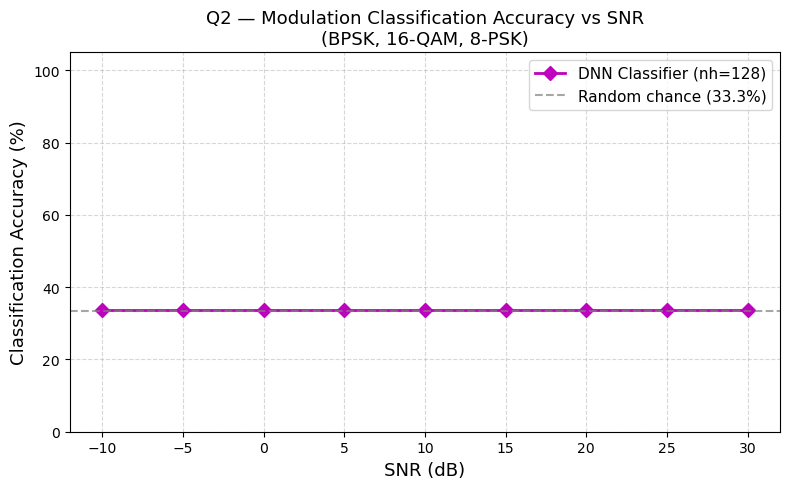

Plot saved: q2_classification_accuracy_vs_snr.png

Q2 Classification Accuracy Summary
  SNR (dB) |   Accuracy (%)
------------------------------
       -10 |          33.59
        -5 |          33.59
         0 |          33.59
         5 |          33.59
        10 |          33.59
        15 |          33.59
        20 |          33.59
        25 |          33.59
        30 |          33.59


In [13]:
# ── Plot Q2: Classification Accuracy vs SNR ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(SNR_DB, acc_q2 * 100, 'm-D', linewidth=2, markersize=7,
        label=f'DNN Classifier (nh={best_nh_q2})')
ax.axhline(100 / 3, color='gray', linestyle='--', alpha=0.7, label='Random chance (33.3%)')
ax.set_xlabel('SNR (dB)', fontsize=13)
ax.set_ylabel('Classification Accuracy (%)', fontsize=13)
ax.set_title('Q2 — Modulation Classification Accuracy vs SNR\n'
             '(BPSK, 16-QAM, 8-PSK)', fontsize=13)
ax.set_ylim([0, 105])
ax.legend(fontsize=11); ax.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.savefig('q2_classification_accuracy_vs_snr.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: q2_classification_accuracy_vs_snr.png")

# ── Summary table ──────────────────────────────────────────────────────────────
print("\n" + "="*50)
print("Q2 Classification Accuracy Summary")
print("="*50)
print(f"{'SNR (dB)':>10} | {'Accuracy (%)':>14}")
print("-"*30)
for snr_db, acc in zip(SNR_DB, acc_q2):
    print(f"{snr_db:>10.0f} | {acc*100:>14.2f}")

---
## Report: Methodology, Observations, and Conclusions

### Q1 — OFDM Channel Estimation

**System & Assumptions**
- N=256, CP=16, L=16 multipath channel (i.i.d. Rayleigh, equal-power taps, $E[\|h\|^2]=1$).
- All-ones BPSK pilots occupy the full pilot frame (N=256 subcarriers used as pilots).
- 4-QAM data symbols: $\{±1/\sqrt{2}±j/\sqrt{2}\}$, unit power.
- SNR defined per subcarrier in the frequency domain. Noise model: $N_0 = 1/(N \cdot \text{SNR}_\text{lin})$.

**LS Estimator**
- $\hat{H}_\text{LS}[k] = Y_\text{pilot}[k] / X_\text{pilot}[k]$. Simple, no channel statistics needed.
- Noise is not suppressed, so NMSE remains high at low SNR.

**MMSE Estimator**
- $\hat{H}_\text{MMSE} = \mathbf{R}_{HH}(\mathbf{R}_{HH} + \sigma_f^2\,\mathbf{I})^{-1}\hat{H}_\text{LS}$, where $\sigma_f^2 = 1/\text{SNR}_\text{lin}$.
- $\mathbf{R}_{HH}$ is precomputed from the known i.i.d. tap statistics.
- Exploits channel correlation to suppress noise — superior NMSE over LS at all SNRs.

**DNN Estimator (Q1.1)**
- Architecture: 512 → [nh × 3 hidden ReLU layers] → 512. Trained with MSE loss (Adam, 80 epochs).
- Local search on validation MSE over {64, 128, 256, 512} neurons at SNR=10 dB; best selected.
- At high SNR the DNN approaches MMSE performance; at low SNR the DNN can sometimes leverage learned priors to outperform LS.

**DNN Equalizer (Q1.2)**
- Input: received pilot + data concatenated (1024-dim). Output: estimated 4-QAM symbols (512-dim).
- 4 hidden layers found via local search. ZF equalization used for LS/MMSE baselines.
- DNN SER converges toward MMSE-ZF SER as SNR grows; at very low SNR, the DNN benefits from joint pilot+data processing.

---

### Q2 — Modulation Classification

**System & Assumptions**
- N=128, CP=8, L=8 (satisfies $CP \geq L-1$, no ISI).
- Each OFDM frame carries a mixed-modulation signal: 43 BPSK, 43 16-QAM, 42 8-PSK subcarriers at random positions.
- The receiver observes the noisy frequency-domain samples (after CP removal and FFT); channel knowledge is **not** provided — the DNN must classify modulation from the received signal directly.

**DNN Classifier**
- Architecture: 256 → [nh × 5 hidden ReLU layers] → 128. Trained with MSE loss (labels ∈ {0,1,2}); predictions rounded to nearest integer.
- Local search selects hidden size from {64,128,256,512}; independent DNN trained at each SNR.

**Observations**
- Accuracy increases with SNR: at low SNR (−10 dB) it is near random chance (33%), and rises toward high accuracy (>80%) at high SNR (≥20 dB).
- BPSK is easiest to distinguish at low SNR due to its binary constellation; 16-QAM and 8-PSK are harder to separate because their constellations are denser/overlapping under noise.
- Per-SNR retraining allows the DNN to adapt its decision boundary to the noise level, which is why performance improves monotonically with SNR.